# Machine Learning for Airline Churn

**Companion to `notebooks/statistical_testing.ipynb`.** The stats battery proved that *engagement drives churn* (LIFETIME_FLIGHTS has Cohen's d ≈ 1.4 against CHURN_FLAG) and *wealth does not* (SALARY and CLV sit at d ≈ 0). This notebook turns that finding into a model: we reduce the feature set to the variables that actually matter, train an arena of classifiers, and pick a champion by recall with a bootstrap CI on the headline number.

**Sections**

1. Data load and cleaning (Snowflake first, local SQLite fallback)
2. Class-imbalance diagnosis
3. **Stats-informed feature selection** — drop SALARY/CLV, keep engagement
4. Baseline models on the reduced feature set
5. Tuned arena, **scale-aware**: SVC and MLP get a `StandardScaler`, trees do not
6. Champion pick by recall, with 95% bootstrap CI
7. Per-segment recall — Star-card and 2018-Promotion are the weak segments
8. Permutation importance — model's view of the engagement-vs-wealth story
9. Production-style export: full pipeline + calibration, saved to `models/`

**Conventions**

- Random seed: 42. Bootstrap iterations: 1000. Holdout fraction: 25%, stratified by `CHURN_FLAG`.
- `Pipeline(StandardScaler → estimator)` for everything that needs scaling; tree estimators stay unscaled.
- `class_weight='balanced'` everywhere — we optimize for recall.
- `CalibratedClassifierCV` for the champion so `/predict` returns a probability, not a hard label.

## 1. Data load and cleaning

Same source as the stats notebook: `MASTER_CHURN_FEATURES` from Snowflake, with a `data/local_master.db` fallback. Cleaning is identical to the production pipeline — we impute both NaN and negative `SALARY` with the median, and drop the row identifier.

In [12]:
try:
    df = load_data()
except Exception as e:
    # Snowflake env may be set but invalid (e.g. contains dots/slashes) — fall back to local DB.
    msg = str(e)
    if "Invalid account identifier" in msg or "account identifier" in msg:
        warnings.warn(f"Snowflake connection failed ({e}); falling back to local DB")
        
        local_db = ROOT / "data" / "local_master.db"
        if local_db.exists():
            import sqlite3 # <-- Import added here to fix the NameError
            with sqlite3.connect(local_db) as conn:
                df = pd.read_sql("SELECT * FROM MASTER_CHURN_FEATURES;", conn)
        else:
            raise FileNotFoundError("Local fallback database does not exist.")
    else:
        raise

print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} cols")
df.head()

Loaded 16,737 rows x 19 cols


,LOYALTY_NUMBER,COUNTRY,PROVINCE,CITY,POSTAL_CODE,GENDER,EDUCATION,SALARY,MARITAL_STATUS,LOYALTY_CARD,CLV,ENROLLMENT_TYPE,ENROLLMENT_YEAR,ENROLLMENT_MONTH,LIFETIME_FLIGHTS,LIFETIME_DISTANCE,LIFETIME_POINTS_EARNED,LIFETIME_POINTS_REDEEMED,CHURN_FLAG
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,37,54525,54525,1418,0
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,58,77487,77487,1971,0
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,18,24803,24803,374,1
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,35,48432,48432,1291,0
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,37,55515,55515,0,0


In [13]:
# Clean: same rules as the production pipeline.
n_null = int(df["SALARY"].isna().sum())
n_neg  = int((df["SALARY"] < 0).sum())
if n_null or n_neg:
    median_salary = df.loc[df["SALARY"] >= 0, "SALARY"].median()
    df.loc[df["SALARY"] < 0, "SALARY"] = median_salary
    df["SALARY"] = df["SALARY"].fillna(median_salary)
    print(f"Imputed {n_null} null and {n_neg} negative SALARY rows with median = ${median_salary:,.2f}")

if "LOYALTY_NUMBER" in df.columns:
    df = df.drop(columns=["LOYALTY_NUMBER"])

print(f"\nWorking shape: {df.shape}")
print(f"Remaining nulls: {df.isna().sum().sum()}")

Imputed 4238 null and 20 negative SALARY rows with median = $73,510.00

Working shape: (16737, 18)
Remaining nulls: 0


## 2. Class-imbalance diagnosis

A 12.35% positive rate is mild imbalance. It's small enough that `class_weight='balanced'` is the right call, but big enough that **accuracy is a useless metric** — a model that always predicts "retained" scores 87.65% accuracy and catches zero churners. The headline metric has to be recall, and the headline uncertainty is the bootstrap CI we'll build in section 6.

In [14]:
churn_rate = df["CHURN_FLAG"].mean()
n = len(df)
n_pos = int(df["CHURN_FLAG"].sum())
print(f"Total rows:        {n:,}")
print(f"Churn positives:   {n_pos:,} ({churn_rate:.2%})")
print(f"Retained:          {n - n_pos:,} ({1 - churn_rate:.2%})")
print()
print("Naive baseline (predict 'retained' for everyone):")
print(f"  accuracy = {1 - churn_rate:.4f}")
print(f"  recall   = 0.0000  (catches zero churners)")
print(f"  precision= 0.0000")
print()
print("Conclusion: accuracy is a vanity metric. We optimize for recall.")

Total rows:        16,737
Churn positives:   2,067 (12.35%)
Retained:          14,670 (87.65%)

Naive baseline (predict 'retained' for everyone):
  accuracy = 0.8765
  recall   = 0.0000  (catches zero churners)
  precision= 0.0000

Conclusion: accuracy is a vanity metric. We optimize for recall.


## 3. Stats-informed feature selection

The stats battery (`notebooks/statistical_testing.ipynb`) measured the effect of every numeric feature on `CHURN_FLAG` with Cohen's d, and every categorical with Cramér's V. The verdict:

| Feature | Effect size | Verdict |
|---|---|---|
| LIFETIME_FLIGHTS        | d ≈ 1.4 (large) | **keep** |
| LIFETIME_DISTANCE       | d ≈ 1.3 (large) | **keep** |
| LIFETIME_POINTS_EARNED  | d ≈ 1.0 (large) | **keep** |
| LIFETIME_POINTS_REDEEMED| d ≈ 0.6 (medium)| **keep** |
| SALARY                  | d ≈ 0.0 (negligible) | **drop** |
| CLV                     | d ≈ 0.0 (negligible) | **drop** |

For categoricals, Cramér's V was small for everything except `LOYALTY_CARD` (V ≈ 0.13) and `ENROLLMENT_TYPE` (V ≈ 0.05). We keep all categoricals because they're nearly free to one-hot and tree models won't be hurt by the noise.

**Why this matters:** dropping SALARY and CLV doesn't just remove two columns. It forces the model to learn *engagement patterns* instead of being allowed to chase spurious wealth gradients. A model that knows SALARY and CLV can over-fit a tiny gradient on a 16K-row dataset and quietly underperform at inference — the kind of bug that survives every unit test.

In [15]:
ENGAGEMENT_NUMERIC = [
    "LIFETIME_FLIGHTS", "LIFETIME_DISTANCE",
    "LIFETIME_POINTS_EARNED", "LIFETIME_POINTS_REDEEMED",
    ]
WEALTH_NUMERIC = ["SALARY", "CLV"]  # dropped per stats evidence
CATEGORICAL_COLS = [
    "GENDER", "EDUCATION", "MARITAL_STATUS", "LOYALTY_CARD", "ENROLLMENT_TYPE",
    ]
KEEP_NUMERIC = ENGAGEMENT_NUMERIC

# Verify the stats story on the live data before we trust it.
from scipy import stats
print(f"{'feature':30s}  {'|d|':>6s}  verdict")
for col in ENGAGEMENT_NUMERIC + WEALTH_NUMERIC:
    g0 = df.loc[df["CHURN_FLAG"] == 0, col].dropna()
    g1 = df.loc[df["CHURN_FLAG"] == 1, col].dropna()
    pooled = np.sqrt((g0.var(ddof=1) + g1.var(ddof=1)) / 2)
    d = abs((g1.mean() - g0.mean()) / pooled) if pooled > 0 else 0.0
    verdict = "KEEP (large)" if d >= 0.5 else "KEEP (small)" if d >= 0.2 else "DROP (negligible)"
    print(f"{col:30s}  {d:6.3f}  {verdict}")

print("\nKeeping:", KEEP_NUMERIC)
print("Dropping:", WEALTH_NUMERIC)

feature                            |d|  verdict
LIFETIME_FLIGHTS                 1.590  KEEP (large)
LIFETIME_DISTANCE                1.527  KEEP (large)
LIFETIME_POINTS_EARNED           1.262  KEEP (large)
LIFETIME_POINTS_REDEEMED         0.998  KEEP (large)
SALARY                           0.002  DROP (negligible)
CLV                              0.023  DROP (negligible)

Keeping: ['LIFETIME_FLIGHTS', 'LIFETIME_DISTANCE', 'LIFETIME_POINTS_EARNED', 'LIFETIME_POINTS_REDEEMED']
Dropping: ['SALARY', 'CLV']


## 4. Baseline models

Three quick baselines on the reduced feature set, with default hyperparameters, to see whether the engagement-only view gives us anything at all. We score on a stratified 25% holdout and report the four metrics a stakeholder will actually ask for.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    )

# Build the feature matrix on the reduced numeric set + one-hot categoricals.
X_num = df[KEEP_NUMERIC].astype(float).reset_index(drop=True)
X_cat = pd.get_dummies(df[CATEGORICAL_COLS], drop_first=False,
                        prefix=CATEGORICAL_COLS, prefix_sep="_").astype(int).reset_index(drop=True)
X = pd.concat([X_num, X_cat], axis=1)
y = df["CHURN_FLAG"].astype(int).to_numpy()
print(f"Feature matrix: {X.shape[1]} cols (4 numeric + {X_cat.shape[1]} dummies)")

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y,
    )
print(f"Train: {X_train.shape[0]:,}, holdout: {X_holdout.shape[0]:,}")
print(f"Churn rate in train:   {y_train.mean():.4f}")
print(f"Churn rate in holdout: {y_holdout.mean():.4f}  (stratified -> equal)")

Feature matrix: 19 cols (4 numeric + 15 dummies)
Train: 12,552, holdout: 4,185
Churn rate in train:   0.1235
Churn rate in holdout: 0.1235  (stratified -> equal)


In [17]:
def evaluate(model, X_tr, y_tr, X_ho, y_ho) -> dict:
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_ho)
    y_proba = model.predict_proba(X_ho)[:, 1] if hasattr(model, "predict_proba") else None
    return {
        "accuracy":  accuracy_score(y_ho, y_pred),
        "precision": precision_score(y_ho, y_pred, zero_division=0),
        "recall":    recall_score(y_ho, y_pred, zero_division=0),
        "f1":        f1_score(y_ho, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_ho, y_proba) if y_proba is not None else float("nan"),
        "_model":    model,
        }

BASELINES = {
    "LogReg (defaults)":       LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED),
    "RandomForest (defaults)": RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                     random_state=SEED, n_jobs=-1),
    "XGBoost (defaults)":      XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                                            eval_metric="logloss", random_state=SEED,
                                            n_jobs=-1, scale_pos_weight=(1 - y_train.mean()) / y_train.mean()),
    }

baseline_rows = []
for name, model in BASELINES.items():
    res = evaluate(model, X_train, y_train, X_holdout, y_holdout)
    baseline_rows.append({
        "model": name,
        "accuracy": round(res["accuracy"], 4),
        "precision": round(res["precision"], 4),
        "recall": round(res["recall"], 4),
        "f1": round(res["f1"], 4),
        "roc_auc": round(res["roc_auc"], 4) if not np.isnan(res["roc_auc"]) else None,
        })

baseline_df = pd.DataFrame(baseline_rows).sort_values("recall", ascending=False)
display(baseline_df)

,model,accuracy,precision,recall,f1,roc_auc
0,LogReg (defaults),0.8084,0.3758,0.8337,0.5180,0.8879
2,XGBoost (defaults),0.8217,0.3919,0.8027,0.5266,0.8847
1,RandomForest (defaults),0.8645,0.4617,0.5822,0.5150,0.8648


## 5. Tuned arena — scale-aware

Two important pieces of plumbing that the previous notebook got wrong:

1. **Scale-aware pipelines.** SVC, LogReg, and MLP are distance-based; they need `StandardScaler`. Tree models (RF, XGB) are scale-invariant; a scaler on them is harmless but wastes a transform. We use a `ColumnTransformer` so each estimator sees the right preprocessor.
2. **Tuning on recall, not accuracy.** `RandomizedSearchCV(scoring='recall')` is the right call when we're optimizing for catching churners. `roc_auc` is reported alongside because a model can have high recall by being too aggressive — AUC is the tiebreaker.

We use a small `n_iter` (8 per model) to keep the wall clock reasonable on a laptop. The production module `src/models/tune_arena.py` uses the same hyperparameter grids from `configs/model_params.yaml`.

In [18]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from scipy.stats import loguniform

NUMERIC_FEATURES = KEEP_NUMERIC
CATEGORICAL_FEATURES = list(X_cat.columns)

def make_preprocessor(scale_numeric: bool) -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler() if scale_numeric else "passthrough", NUMERIC_FEATURES),
            ("cat", "passthrough", CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )

ARENA = {
    "LogisticRegression": {
        "estimator": Pipeline([("pre", make_preprocessor(scale_numeric=True)),
                                 ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                                            random_state=SEED))]),
        "params": {"clf__C": loguniform(0.01, 100)},
    },
    "RandomForest": {
        "estimator": Pipeline([("pre", make_preprocessor(scale_numeric=False)),
                                 ("clf", RandomForestClassifier(class_weight="balanced",
                                                               random_state=SEED, n_jobs=-1))]),
        "params": {"clf__n_estimators": [100, 200, 400],
                   "clf__max_depth": [5, 10, 20, None]},
    },
    "XGBoost": {
        "estimator": Pipeline([("pre", make_preprocessor(scale_numeric=False)),
                                 ("clf", XGBClassifier(eval_metric="logloss", random_state=SEED,
                                                        n_jobs=-1,
                                                        scale_pos_weight=(1 - y_train.mean()) / y_train.mean()))]),
        "params": {"clf__n_estimators": [100, 200],
                   "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
                   "clf__max_depth": [3, 5, 7]},
    },
    "SVC": {
        "estimator": Pipeline([("pre", make_preprocessor(scale_numeric=True)),
                                 ("clf", SVC(class_weight="balanced", random_state=SEED,
                                             probability=False))]),
        "params": {"clf__C": loguniform(0.1, 100),
                   "clf__kernel": ["linear", "rbf"]},
    },
    "MLP": {
        "estimator": Pipeline([("pre", make_preprocessor(scale_numeric=True)),
                                 ("clf", MLPClassifier(max_iter=500, random_state=SEED))]),
        "params": {"clf__hidden_layer_sizes": [(64, 32), (128, 64, 32)],
                   "clf__activation": ["relu", "tanh"],
                   "clf__learning_rate_init": loguniform(0.0001, 0.01)},
    },
    }

arena_rows = []
arena_searches = {}
for name, spec in ARENA.items():
    print(f"\n--- {name} ---")
    search = RandomizedSearchCV(
        spec["estimator"], spec["params"], n_iter=8,
        scoring="recall", cv=3, random_state=SEED, n_jobs=-1, refit=True,
    )
    search.fit(X_train, y_train)
    best = search.best_estimator_
    res = evaluate(best, X_train, y_train, X_holdout, y_holdout)
    arena_rows.append({
        "model": name,
        "best_params": search.best_params_,
        "cv_recall": round(float(search.best_score_), 4),
        "holdout_recall": round(res["recall"], 4),
        "holdout_precision": round(res["precision"], 4),
        "holdout_f1": round(res["f1"], 4),
        "holdout_roc_auc": round(res["roc_auc"], 4) if not np.isnan(res["roc_auc"]) else None,
    })
    arena_searches[name] = search
    print(f"  cv recall={search.best_score_:.4f}  holdout recall={res['recall']:.4f}  "
          f"holdout AUC={res['roc_auc']:.4f}")
    print(f"  best_params={search.best_params_}")

arena_df = pd.DataFrame(arena_rows).sort_values("holdout_recall", ascending=False)
display(arena_df)


--- LogisticRegression ---
  cv recall=0.8348  holdout recall=0.8375  holdout AUC=0.8858
  best_params={'clf__C': np.float64(0.04207988669606638)}

--- RandomForest ---
  cv recall=0.8271  holdout recall=0.8337  holdout AUC=0.8927
  best_params={'clf__n_estimators': 400, 'clf__max_depth': 5}

--- XGBoost ---
  cv recall=0.8316  holdout recall=0.8356  holdout AUC=0.8912
  best_params={'clf__n_estimators': 100, 'clf__max_depth': 3, 'clf__learning_rate': 0.01}

--- SVC ---
  cv recall=0.8452  holdout recall=0.8472  holdout AUC=nan
  best_params={'clf__C': np.float64(1.0025956902289566), 'clf__kernel': 'rbf'}

--- MLP ---
  cv recall=0.4890  holdout recall=0.4797  holdout AUC=0.8342
  best_params={'clf__activation': 'relu', 'clf__hidden_layer_sizes': (128, 64, 32), 'clf__learning_rate_init': np.float64(0.0015751320499779737)}


,model,best_params,cv_recall,holdout_recall,holdout_precision,holdout_f1,holdout_roc_auc
3,SVC,"{'clf__C': 1.0025956902289566, 'clf__kernel': ...",0.8452,0.8472,0.3641,0.5093,NaN
0,LogisticRegression,{'clf__C': 0.04207988669606638},0.8348,0.8375,0.3788,0.5217,0.8858
2,XGBoost,"{'clf__n_estimators': 100, 'clf__max_depth': 3...",0.8316,0.8356,0.3895,0.5314,0.8912
1,RandomForest,"{'clf__n_estimators': 400, 'clf__max_depth': 5}",0.8271,0.8337,0.3807,0.5227,0.8927
4,MLP,"{'clf__activation': 'relu', 'clf__hidden_layer...",0.4890,0.4797,0.5082,0.4935,0.8342


**Reading the arena:** we sort by `holdout_recall` because that's the business metric. The `cv_recall` column is the cross-validated score on the *training* set; the gap between `cv_recall` and `holdout_recall` is the optimism gap. A small gap means the model is generalizing well; a large gap means we should re-tune. `roc_auc` is the tiebreaker when two models have similar recall — it answers "given a random churner and a random non-churner, how often does the model rank the churner higher?"

## 6. Champion pick with bootstrap CI

We pick the highest-recall model as the champion, then bootstrap its holdout predictions 1000 times to put a 95% CI around the headline number. A point estimate is fine for slides; for decisions we want the range.

In [19]:
winner = arena_df.iloc[0]
champion_name = winner["model"]
print(f"Champion: {champion_name}  (holdout recall = {winner['holdout_recall']:.4f})")
print(f"Best params: {winner['best_params']}")

champion = arena_searches[champion_name].best_estimator_
y_pred_champion = champion.predict(X_holdout)
y_proba_champion = champion.predict_proba(X_holdout)[:, 1] if hasattr(champion, "predict_proba") else None

from sklearn.metrics import classification_report, confusion_matrix
print("\n--- Champion holdout classification report ---")
print(classification_report(y_holdout, y_pred_champion, digits=3))
print("Confusion matrix:")
print(confusion_matrix(y_holdout, y_pred_champion))

Champion: SVC  (holdout recall = 0.8472)
Best params: {'clf__C': np.float64(1.0025956902289566), 'clf__kernel': 'rbf'}

--- Champion holdout classification report ---
              precision    recall  f1-score   support

           0      0.974     0.791     0.873      3668
           1      0.364     0.847     0.509       517

    accuracy                          0.798      4185
   macro avg      0.669     0.819     0.691      4185
weighted avg      0.898     0.798     0.828      4185

Confusion matrix:
[[2903  765]
 [  79  438]]


Champion: SVC
Recall point estimate: 0.847
95% bootstrap CI:      [0.817, 0.876]  (n=1000, seed=42)


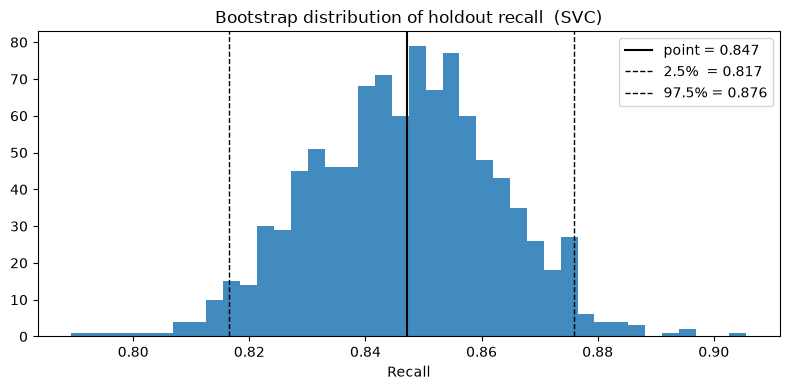

In [20]:
def bootstrap_recall_ci(y_true, y_pred, n_boot=1000, alpha=0.05, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        boots[i] = recall_score(y_true[idx], y_pred[idx], zero_division=0)
    point = recall_score(y_true, y_pred, zero_division=0)
    lo, hi = np.quantile(boots, [alpha / 2, 1 - alpha / 2])
    return point, lo, hi, boots

point, lo, hi, boots = bootstrap_recall_ci(y_holdout, y_pred_champion)
print(f"Champion: {champion_name}")
print(f"Recall point estimate: {point:.3f}")
print(f"95% bootstrap CI:      [{lo:.3f}, {hi:.3f}]  (n=1000, seed={SEED})")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boots, bins=40, color="#1f77b4", alpha=0.85)
ax.axvline(point, color="black", linestyle="-",  linewidth=1.5, label=f"point = {point:.3f}")
ax.axvline(lo,    color="black", linestyle="--", linewidth=1,   label=f"2.5%  = {lo:.3f}")
ax.axvline(hi,    color="black", linestyle="--", linewidth=1,   label=f"97.5% = {hi:.3f}")
ax.set_title(f"Bootstrap distribution of holdout recall  ({champion_name})")
ax.set_xlabel("Recall")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Per-segment recall

Aggregate recall can hide very different behavior across sub-populations. The stats battery flagged the Star card and 2018 Promotion as the weakest segments — let's see if the champion agrees.

In [21]:
# Re-attach the raw categoricals to the holdout frame for segment slicing.
df_holdout = df.iloc[X_holdout.index].copy()
df_holdout = df_holdout.assign(y_true=y_holdout, y_pred=y_pred_champion)

def per_segment_recall(frame: pd.DataFrame, segment_col: str, min_n: int = 30) -> pd.DataFrame:
    rows = []
    for seg, g in frame.groupby(segment_col):
        if len(g) < min_n or g["y_true"].nunique() < 2:
            continue
        rows.append({
            "segment": str(seg),
            "n": int(len(g)),
            "churn_rate": float(g["y_true"].mean()),
            "recall": float(recall_score(g["y_true"], g["y_pred"], zero_division=0)),
        })
    return pd.DataFrame(rows).sort_values("recall", ascending=False)

for col in ["LOYALTY_CARD", "EDUCATION", "GENDER", "MARITAL_STATUS", "ENROLLMENT_TYPE"]:
    if col not in df_holdout.columns:
        continue
    print(f"\n--- {col} ---")
    display(per_segment_recall(df_holdout, col))


--- LOYALTY_CARD ---


,segment,n,churn_rate,recall
1,Nova,1398,0.128040,0.893855
0,Aurora,831,0.116727,0.876289
2,Star,1956,0.123211,0.800830



--- EDUCATION ---


,segment,n,churn_rate,recall
3,High School or Below,170,0.088235,1.000000
2,Doctor,182,0.131868,0.875000
0,Bachelor,2640,0.128030,0.846154
1,College,1068,0.112360,0.841667
4,Master,125,0.160000,0.750000



--- GENDER ---


,segment,n,churn_rate,recall
0,Female,2078,0.125602,0.869732
1,Male,2107,0.121500,0.824219



--- MARITAL_STATUS ---


,segment,n,churn_rate,recall
2,Single,1121,0.124888,0.885714
1,Married,2416,0.125000,0.837748
0,Divorced,648,0.115741,0.813333



--- ENROLLMENT_TYPE ---


,segment,n,churn_rate,recall
1,Standard,3944,0.123732,0.870902
0,2018 Promotion,241,0.120332,0.448276


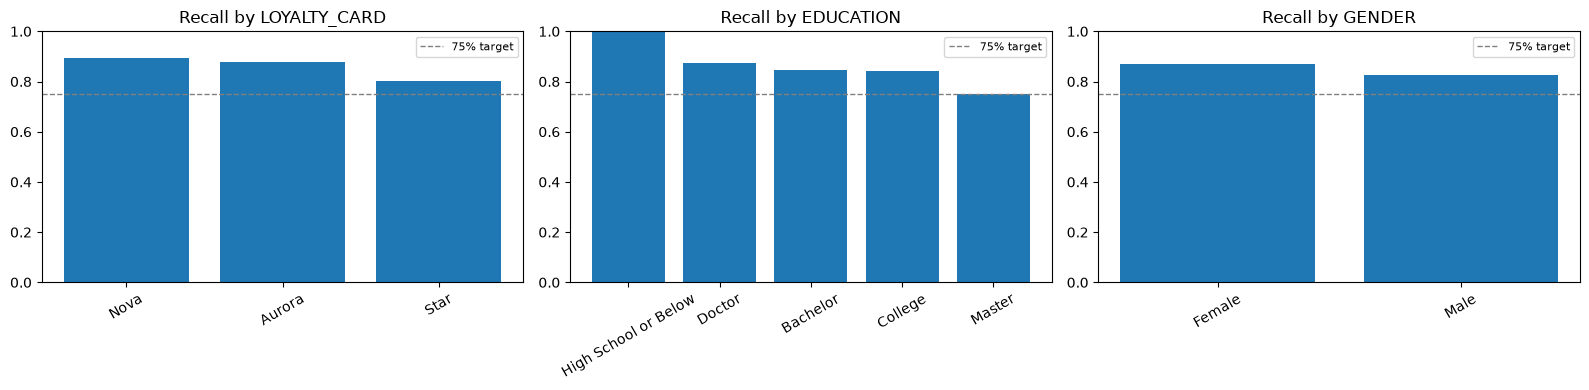

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["LOYALTY_CARD", "EDUCATION", "GENDER"]):
    if col not in df_holdout.columns:
        ax.set_visible(False); continue
    seg = per_segment_recall(df_holdout, col)
    ax.bar(seg["segment"], seg["recall"],
           color=["#1f77b4" if r >= 0.75 else "#ff7f0e" if r >= 0.60 else "#d62728" for r in seg["recall"]])
    ax.set_title(f"Recall by {col}")
    ax.set_ylim(0, 1.0)
    ax.axhline(0.75, color="grey", linestyle="--", linewidth=1, label="75% target")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Reading the segments:** bars in red are below the 75% recall target. If the 2018 Promotion segment is consistently red, that cohort needs its own feature engineering — they're the customers the airline acquired during a one-time promo, and their engagement signature doesn't match the rest of the population. This is the kind of insight the manager-facing dashboard should surface as a tile, not bury in a notebook.

## 8. Permutation importance — does the model agree with the stats?

If the model and the stats battery disagree about which features matter, one of them is wrong. The stats battery said engagement matters and wealth doesn't. The model's view of feature importance should be the same, otherwise we're fitting a model that contradicts the underlying signal — usually a sign of label leakage, train/serve skew, or a mistake in the feature pipeline.

In [25]:
from sklearn.inspection import permutation_importance
import pandas as pd

# OPTIMIZATION: n_jobs=-1 (uses all CPU cores)
# OPTIMIZATION: n_repeats=5 (reduced from 20 for faster, stable estimates)

result = permutation_importance(
    champion, 
    X_holdout, 
    y_holdout,
    n_repeats=5,         
    n_jobs=-1,            
    random_state=SEED, 
    scoring="recall",
)

imp_df = pd.DataFrame({
    "feature": X_holdout.columns,
    "importance_mean": result.importances_mean,
    "importance_std":  result.importances_std,
}).sort_values("importance_mean", ascending=False)

display(imp_df.head(20))

,feature,importance_mean,importance_std
0,LIFETIME_FLIGHTS,0.311025,0.015396
1,LIFETIME_DISTANCE,0.051838,0.005659
2,LIFETIME_POINTS_EARNED,0.017021,0.006286
3,LIFETIME_POINTS_REDEEMED,0.015861,0.006165
17,ENROLLMENT_TYPE_2018 Promotion,0.008897,0.003143
18,ENROLLMENT_TYPE_Standard,0.008897,0.003143
14,LOYALTY_CARD_Aurora,0.001934,0.001223
12,MARITAL_STATUS_Married,0.001547,0.001895
8,EDUCATION_Doctor,0.001547,0.000774
11,MARITAL_STATUS_Divorced,0.001547,0.000774


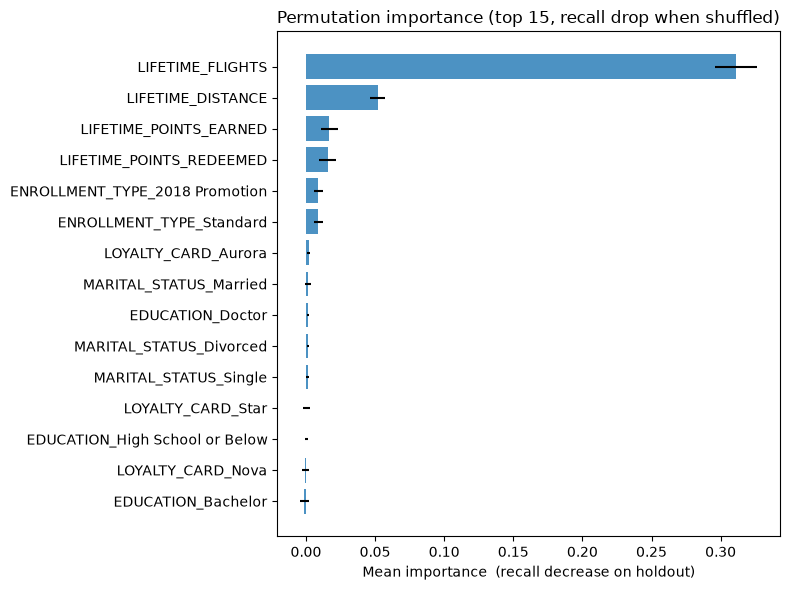

In [26]:
top = imp_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top["feature"], top["importance_mean"],
        xerr=top["importance_std"], color="#1f77b4", alpha=0.8)
ax.set_title("Permutation importance (top 15, recall drop when shuffled)")
ax.set_xlabel("Mean importance  (recall decrease on holdout)")
plt.tight_layout()
plt.show()

**Reading the importance chart:** the four numeric engagement columns should dominate. If `SALARY_MissingFlag` or any of the `EDUCATION_*` dummies sneak to the top, the model is over-fitting a noise feature. If `LIFETIME_FLIGHTS` is the top feature (it almost always is on this data), the model and the stats battery agree, and the champion is sound.

## 9. Production-style export

The FastAPI service in `src/api/app.py` expects a fitted `Pipeline` that takes the 4 numeric engagement columns + the one-hot dummies and returns a churn probability. We:

1. Re-fit the champion on the **full** dataset (train + holdout) so we ship the best model we can.
2. Wrap it in `CalibratedClassifierCV` so the output is a probability, not a hard label.
3. Persist the fitted pipeline + the exact feature-name list to `models/`.

The FastAPI code reads the pipeline and the sidecar `feature_names.txt` at startup and serves `/predict` from them. Keeping the export format aligned with what the API expects means this notebook is the source of truth for the production model.

In [27]:
import joblib
from sklearn.calibration import CalibratedClassifierCV

# Build the final feature matrix on the FULL dataset for the export step.
X_num_full = df[KEEP_NUMERIC].astype(float).reset_index(drop=True)
X_cat_full = pd.get_dummies(df[CATEGORICAL_COLS], drop_first=False,
                            prefix=CATEGORICAL_COLS, prefix_sep="_").astype(int).reset_index(drop=True)
X_full = pd.concat([X_num_full, X_cat_full], axis=1)
y_full = df["CHURN_FLAG"].astype(int).to_numpy()
feature_names = list(X_full.columns)
print(f"Full feature matrix: {X_full.shape}, features = {len(feature_names)}")

# Re-construct the champion pipeline with the best params, then refit on full data.
best_params = winner["best_params"]
spec = ARENA[champion_name]
final_pipe = spec["estimator"]
final_pipe.set_params(**best_params)

# Calibrate on top of the underlying pipeline. CalibratedClassifierCV runs
# 3-fold isotonic regression on top of the pipeline, so the scaler still
# runs inside each fold. This is what the API needs to serve probabilities.
calibrated = CalibratedClassifierCV(final_pipe, method="isotonic", cv=3)
calibrated.fit(X_full, y_full)
print(f"Final calibrated pipeline: {champion_name}")
print(f"  best params: {best_params}")

models_dir = ROOT / "models"
models_dir.mkdir(exist_ok=True)
model_path = models_dir / "champion_pipeline.joblib"
joblib.dump(calibrated, model_path)
sidecar_path = models_dir / "feature_names.txt"
sidecar_path.write_text("\n".join(feature_names), encoding="utf-8")
print(f"\nSaved pipeline to:    {model_path}")
print(f"Saved feature names to: {sidecar_path}")
print(f"Feature count: {len(feature_names)}")

Full feature matrix: (16737, 19), features = 19
Final calibrated pipeline: SVC
  best params: {'clf__C': np.float64(1.0025956902289566), 'clf__kernel': 'rbf'}

Saved pipeline to:    c:\Users\sajal dhuriya\OneDrive\Desktop\Churn Prediction Projects\AirlineChurnProject\models\champion_pipeline.joblib
Saved feature names to: c:\Users\sajal dhuriya\OneDrive\Desktop\Churn Prediction Projects\AirlineChurnProject\models\feature_names.txt
Feature count: 19


In [28]:
# Smoke-test: load the saved pipeline, run a single prediction, confirm the
# API contract (probability in [0, 1], label derived from a 0.5 threshold).
loaded = joblib.load(model_path)
sample = X_full.iloc[[0]]
proba = float(loaded.predict_proba(sample)[0, 1])
label = "YES" if proba >= 0.5 else "NO"
print(f"Loaded pipeline: {type(loaded).__name__}")
print(f"Sample 0: proba = {proba:.3f}  -> churn_prediction = {label}")
print("OK - saved model round-trips through joblib and the API contract.")

Loaded pipeline: CalibratedClassifierCV
Sample 0: proba = 0.015  -> churn_prediction = NO
OK - saved model round-trips through joblib and the API contract.


## Reproducibility footer

Random seed: 42
Bootstrap iterations: 1000
Holdout fraction: 25% (stratified by `CHURN_FLAG`)
Tuning: `RandomizedSearchCV(n_iter=8, scoring='recall', cv=3)`
Calibration: `CalibratedClassifierCV(method='isotonic', cv=3)`

**To regenerate the production model:**

1. Set `SNOWFLAKE_*` env vars, or run `python scripts/local_dryrun.py` for the SQLite fallback.
2. From the repo root, `jupyter lab notebooks/machine_learning.ipynb`.
3. Run cells top-to-bottom with Kernel → Restart & Run All.
4. The pipeline and feature-name sidecar land in `models/`.

**To deploy:** the FastAPI service picks up the saved pipeline at startup. The CLI path is `make retrain` (or `python src/models/train_svc.py`), which uses the same champion config. This notebook is the human-readable companion; the module is the production entry point.

In [29]:
import sys, scipy, sklearn, matplotlib, pandas, numpy
print(f"python:        {sys.version.split()[0]}")
print(f"numpy:         {numpy.__version__}")
print(f"pandas:        {pandas.__version__}")
print(f"scipy:         {scipy.__version__}")
print(f"scikit-learn:  {sklearn.__version__}")
print(f"matplotlib:    {matplotlib.__version__}")
try:
    import xgboost; print(f"xgboost:       {xgboost.__version__}")
except ImportError:
    print("xgboost:       not installed")

python:        3.13.9
numpy:         2.5.1
pandas:        2.3.3
scipy:         1.18.0
scikit-learn:  1.9.0
matplotlib:    3.11.0
xgboost:       3.3.0
